In [ ]:
from google.colab import files
uploaded = files.upload()

Saving shl_pretrain_coarse_balanced.npz to shl_pretrain_coarse_balanced (1).npz


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

shl = np.load("shl_pretrain_coarse_balanced.npz", allow_pickle=True)

X = shl["X"]              # (N,125,7)
y = shl["y"]              # strings
modes = list(shl["modes"])

print("X shape:", X.shape)
print("Modes:", modes)

X shape: (4030, 125, 7)
Modes: ['train', 'subway', 'car', 'bus', 'walk']


In [ ]:
mode_to_idx = {m:i for i,m in enumerate(modes)}
y_i = np.array([mode_to_idx[v] for v in y], dtype=np.int64)

In [ ]:
X = X[..., np.newaxis].astype(np.float32)  # (N,125,7,1)

In [ ]:
rng = np.random.default_rng(42)
idx = rng.permutation(len(y_i))
split = int(0.8 * len(idx))

tr_idx, va_idx = idx[:split], idx[split:]

X_tr, y_tr = X[tr_idx], y_i[tr_idx]
X_va, y_va = X[va_idx], y_i[va_idx]

print("Train:", X_tr.shape, "Val:", X_va.shape)

Train: (3224, 125, 7, 1) Val: (806, 125, 7, 1)


In [ ]:
eps = 1e-8
mu = X_tr.mean(axis=(0,1), keepdims=True)
sigma = X_tr.std(axis=(0,1), keepdims=True) + eps

X_tr = (X_tr - mu) / sigma
X_va = (X_va - mu) / sigma

In [ ]:
def build_model(n_classes, input_shape=(125,7,1)):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(16, (5,1), activation="relu", padding="same"),
        tf.keras.layers.MaxPool2D((2,1)),
        tf.keras.layers.Conv2D(32, (5,1), activation="relu", padding="same"),
        tf.keras.layers.MaxPool2D((2,1)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(n_classes, activation="softmax")
    ])
    return model

model = build_model(len(modes), X_tr.shape[1:])
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 125, 7, 16)     │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 7, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 62, 7, 32)      │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 31, 7, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       444,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 447,493 (1.71 MB)

 Trainable params: 447,493 (1.71 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.6528 - loss: 0.8929 - val_accuracy: 0.8561 - val_loss: 0.4479
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.8519 - loss: 0.4002 - val_accuracy: 0.9181 - val_loss: 0.3094
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.9101 - loss: 0.2582 - val_accuracy: 0.9541 - val_loss: 0.2278
Epoch 4/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.9122 - loss: 0.2430 - val_accuracy: 0.9566 - val_loss: 0.2083
Epoch 5/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9425 - loss: 0.1817 - val_accuracy: 0.9578 - val_loss: 0.2168
Epoch 6/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.9603 - loss: 0.1388 - val_accuracy: 0.9677 - val_loss: 0.1902
Epoch 7/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.9564 - loss: 0.1304 - val_accuracy: 0.9690 - val_loss: 0.2103
Epoch 8/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.9713 - loss: 0.1052 - val_accuracy: 0.9541 - v

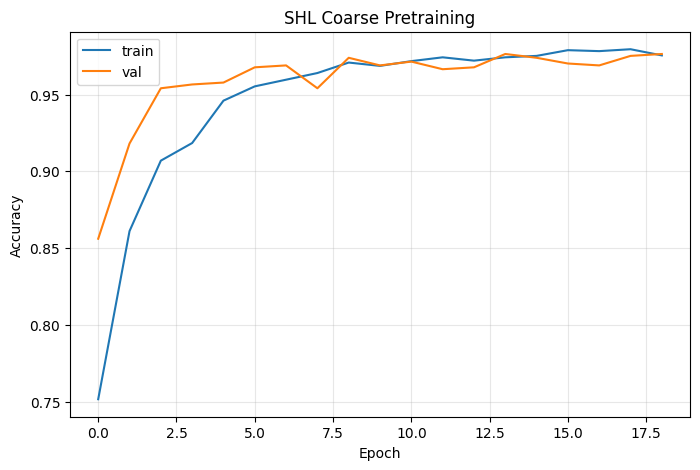

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("SHL Coarse Pretraining")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

SHL VAL accuracy: 0.9764267802238464
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


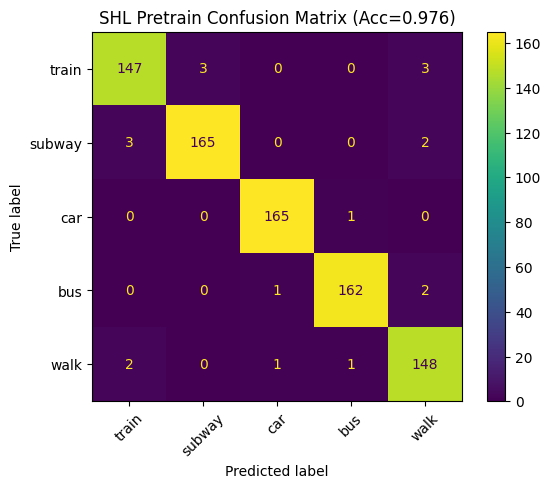

In [ ]:
val_loss, val_acc = model.evaluate(X_va, y_va, verbose=0)
print("SHL VAL accuracy:", val_acc)

y_pred = np.argmax(model.predict(X_va), axis=1)

cm = confusion_matrix(y_va, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=modes)
disp.plot(cmap=None, xticks_rotation=45, values_format="d")
plt.title(f"SHL Pretrain Confusion Matrix (Acc={val_acc:.3f})")
plt.show()

In [ ]:
model.save("pretrained_shl_coarse.keras")
print("Saved pretrained_shl_coarse.keras")

Saved pretrained_shl_coarse.keras


In [ ]:
files.download("pretrained_shl_coarse.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving baseline_features_v3_segment_split_train_val_test.npz to baseline_features_v3_segment_split_train_val_test (1).npz


In [ ]:
import numpy as np

selfd = np.load("baseline_features_v3_segment_split_train_val_test.npz", allow_pickle=True)

print("Keys:", list(selfd.keys()))
print("X_train:", selfd["X_train"].shape)
print("X_val:",   selfd["X_val"].shape)
print("X_test:",  selfd["X_test"].shape)
print("modes:", list(selfd["modes"]))

Keys: ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test', 'feature_cols', 'modes', 'mu', 'sigma', 'fs_hz', 'win_s', 'overlap', 'split_report', 'note']
X_train: (840, 125, 7)
X_val: (1246, 125, 7)
X_test: (240, 125, 7)
modes: ['train', 'subway', 'car', 'bus', 'walk']


In [ ]:
import numpy as np

modes = list(selfd["modes"])
mode_to_idx = {m:i for i,m in enumerate(modes)}

X_train = selfd["X_train"].astype(np.float32)[..., np.newaxis]
X_val   = selfd["X_val"].astype(np.float32)[..., np.newaxis]
X_test  = selfd["X_test"].astype(np.float32)[..., np.newaxis]

y_train = np.array([mode_to_idx[v] for v in selfd["y_train"]], dtype=np.int64)
y_val   = np.array([mode_to_idx[v] for v in selfd["y_val"]], dtype=np.int64)
y_test  = np.array([mode_to_idx[v] for v in selfd["y_test"]], dtype=np.int64)

print("Train:", X_train.shape, y_train.shape)
print("Val:",   X_val.shape, y_val.shape)
print("Test:",  X_test.shape, y_test.shape)

Train: (840, 125, 7, 1) (840,)
Val: (1246, 125, 7, 1) (1246,)
Test: (240, 125, 7, 1) (240,)


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving pretrained_shl_coarse.keras to pretrained_shl_coarse (3).keras


In [ ]:
import tensorflow as tf

pretrained = tf.keras.models.load_model("pretrained_shl_coarse.keras")
pretrained.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 125, 7, 16)     │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 7, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 62, 7, 32)      │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 31, 7, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6944)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       444,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,342,481 (5.12 MB)

 Trainable params: 447,493 (1.71 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 894,988 (3.41 MB)

In [ ]:
def build_model(n_classes, input_shape=(125,7,1)):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(16, (5,1), activation="relu", padding="same"),
        tf.keras.layers.MaxPool2D((2,1)),
        tf.keras.layers.Conv2D(32, (5,1), activation="relu", padding="same"),
        tf.keras.layers.MaxPool2D((2,1)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(n_classes, activation="softmax")
    ])
    return model

self_model = build_model(len(modes), X_train.shape[1:])
self_model.set_weights(pretrained.get_weights())  # transfer
print("Weights transferred.")

Weights transferred.


In [ ]:
# freeze feature extractor
for layer in self_model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D) or isinstance(layer, tf.keras.layers.MaxPool2D):
        layer.trainable = False

self_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

hist_lp = self_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7161 - loss: 1.7980 - val_accuracy: 0.7673 - val_loss: 1.2501
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9950 - loss: 0.0291 - val_accuracy: 0.6742 - val_loss: 1.9254
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9979 - loss: 0.0102 - val_accuracy: 0.6292 - val_loss: 2.5629
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.9864 - loss: 0.0238 - val_accuracy: 0.5867 - val_loss: 3.0469
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9997 - loss: 0.0058 - val_accuracy: 0.5706 - val_loss: 3.3967
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9990 - loss: 0.0056 - val_accuracy: 0.5787 - val_loss: 3.3409
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9986 - loss: 0.0109 - val_accuracy: 0.5803 - val_loss: 3.3708
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9992 - loss: 0.0046 - val_accuracy: 0.5152 - v

In [ ]:
test_loss, test_acc = self_model.evaluate(X_test, y_test, verbose=0)
print(f"TEST accuracy (linear probe): {test_acc:.4f}")

TEST accuracy (linear probe): 0.7958


In [ ]:
for layer in self_model.layers:
    layer.trainable = True

self_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),  # lower LR
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True)
]

hist_ft = self_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

test_loss, test_acc = self_model.evaluate(X_test, y_test, verbose=0)
print(f"TEST accuracy (fine-tuned): {test_acc:.4f}")

Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 1.0000 - loss: 5.1669e-04 - val_accuracy: 0.5056 - val_loss: 8.8282
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.9979 - loss: 0.0028 - val_accuracy: 0.5048 - val_loss: 8.8960
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.5088 - val_loss: 8.6265
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 1.0000 - loss: 1.8884e-04 - val_accuracy: 0.5096 - val_loss: 8.7385
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 1.0000 - loss: 3.4948e-04 - val_accuracy: 0.5104 - val_loss: 8.8851
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 1.0000 - loss: 5.0101e-04 - val_accuracy: 0.5048 - val_loss: 9.1923
Epoch 7/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 1.0000 - loss: 6.7746e-04 - val_accuracy: 0.5096 - val_loss: 9.5004
Epoch 8/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9995 - loss: 0.0015 - val_